# SHA-256 Avalanche Effect — Audio Steganography Failure Mode Analysis

This notebook demonstrates the **binary failure mode** of the proposed method under lossy compression.

**Core claim**: Because the PRNG seed is derived from SHA-256 of the 1024-sample anchor, even a single-bit perturbation (as introduced by any MP3/AAC compression) causes:
- Complete hash randomisation (avalanche criterion)
- Full Fisher-Yates permutation desynchronisation  
- Immediate BER → ~50% (random noise floor)

**References**:
- Webster & Tavares (1986): Strict Avalanche Criterion
- Painter & Spanias (2000): MP3/AAC quantisation noise

In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.io import wavfile
import warnings
warnings.filterwarnings('ignore')

# ── Optional: load a real WAV file ──────────────────────────────────────────
# If you have the MUSDB18-HQ track, set the path below.
# Otherwise, the notebook generates a synthetic signal.
WAV_PATH = None  # e.g. "Al James - Schoolboy Fascination_bass.wav"
ANCHOR_LEN = 1024       # N_A  — number of samples used for SHA-256 anchor
PAYLOAD_BITS = 100_000  # simulated payload size in bits
SEED_BYTES = 32         # SHA-256 output = 32 bytes = 256 bits
N_TRIALS = 500          # Monte Carlo trials per noise level

print("Libraries loaded.")

Libraries loaded.


## 1. Load or Generate Audio Signal

In [ ]:
if WAV_PATH is not None:
    sr, audio = wavfile.read(WAV_PATH)
    if audio.ndim > 1:
        audio = audio[:, 0]   # mono
    audio = audio.astype(np.int16)
    print(f"Loaded: {WAV_PATH}  |  sr={sr} Hz  |  samples={len(audio):,}")
else:
    # Synthetic 16-bit PCM signal (white noise — worst case for steganography)
    rng = np.random.default_rng(42)
    audio = rng.integers(-32768, 32767, size=17_686_462, dtype=np.int16)
    sr = 44100
    print(f"Synthetic audio generated  |  sr={sr} Hz  |  samples={len(audio):,}")

anchor_clean = audio[:ANCHOR_LEN].copy()
print(f"Anchor region: samples 0 – {ANCHOR_LEN-1}")

Synthetic audio generated  |  sr=44100 Hz  |  samples=17,686,462
Anchor region: samples 0 – 1023


## 2. Helper Functions

In [ ]:
def sha256_seed(samples: np.ndarray) -> int:
    """Compute SHA-256 of raw sample bytes → integer seed."""
    raw = samples.astype(np.int16).tobytes()
    digest = hashlib.sha256(raw).digest()
    return int.from_bytes(digest, 'big')


def fisher_yates_permutation(seed: int, n: int) -> np.ndarray:
    """Generate Fisher-Yates permutation of length n from seed."""
    rng = np.random.default_rng(seed % (2**63))  # numpy needs 63-bit seed
    idx = np.arange(n)
    rng.shuffle(idx)
    return idx

def compute_ber(perm_a: np.ndarray, perm_b: np.ndarray) -> float:
    """
    BER ước tính: mỗi vị trí extract sai → bit đó random (50% sai).
    Nếu perm hoàn toàn desync → BER = 0.50, không phải 1.0
    """
    mismatch_rate = np.mean(perm_a != perm_b)
    # Mỗi position sai → bit đó bị randomised → 0.5 xác suất sai
    return mismatch_rate * 0.5


def add_quantisation_noise(anchor: np.ndarray, noise_level: int,
                           rng: np.random.Generator) -> np.ndarray:
    """
    Simulate MP3/AAC quantisation noise.
    noise_level = max absolute integer perturbation per sample.
    noise_level=0  → lossless (no change)
    noise_level=1  → minimal lossy (±1 LSB, models ~320 kbps MP3)
    noise_level=N  → stronger compression artefacts
    """
    noise = rng.integers(-noise_level, noise_level + 1, size=len(anchor))
    noisy = anchor.astype(np.int32) + noise
    return np.clip(noisy, -32768, 32767).astype(np.int16)


print("Helper functions defined.")

Helper functions defined.


## 3. Experiment A — Single-Bit Flip (Strict Avalanche Criterion)

Flip exactly **one bit** in the anchor (the theoretical minimum perturbation) and measure the resulting BER.

In [ ]:
seed_clean = sha256_seed(anchor_clean)
perm_clean = fisher_yates_permutation(seed_clean, PAYLOAD_BITS)

ber_per_bit = []
hash_hamming = []

# Flip each bit position in the first sample for illustration
for bit_pos in range(16):   # 16-bit sample
    anchor_flipped = anchor_clean.copy()
    # Cast to int32 để tránh overflow khi XOR
    val = anchor_flipped[0].astype(np.int32)
    val ^= (1 << bit_pos)
    # Wrap lại về int16 range
    anchor_flipped[0] = np.int16(np.clip(val, -32768, 32767))
    seed_flipped = sha256_seed(anchor_flipped)
    perm_flipped = fisher_yates_permutation(seed_flipped, PAYLOAD_BITS)

    ber = compute_ber(perm_clean, perm_flipped)
    ber_per_bit.append(ber)

    # Hamming distance between the two 256-bit hashes
    h1 = bin(seed_clean).count('1')
    h2 = bin(seed_flipped).count('1')
    xor = seed_clean ^ seed_flipped
    hd = bin(xor).count('1')
    hash_hamming.append(hd)

print("Single-bit flip results:")
print(f"  Mean BER across 16 bit positions : {np.mean(ber_per_bit):.4f}  (expected ~0.50)")
print(f"  Mean hash Hamming distance       : {np.mean(hash_hamming):.1f} / 256 bits  (expected ~128)")
print(f"  Min BER : {min(ber_per_bit):.4f}")
print(f"  Max BER : {max(ber_per_bit):.4f}")

Single-bit flip results:
  Mean BER across 16 bit positions : 0.5000  (expected ~0.50)
  Mean hash Hamming distance       : 128.2 / 256 bits  (expected ~128)
  Min BER : 0.5000
  Max BER : 0.5000


## 4. Experiment B — BER vs Quantisation Noise Level (Monte Carlo)

Sweep noise_level from 0 (lossless) to 50 (heavy compression artefacts).  
For each level, run N_TRIALS random noise realisations and record mean BER.

In [ ]:
noise_levels = [0, 1, 2, 3, 5, 8, 10, 15, 20, 30, 50]
rng_mc = np.random.default_rng(2024)

results = {}
for nl in noise_levels:
    bers = []
    for _ in range(N_TRIALS):
        if nl == 0:
            anchor_noisy = anchor_clean.copy()
        else:
            anchor_noisy = add_quantisation_noise(anchor_clean, nl, rng_mc)

        seed_noisy = sha256_seed(anchor_noisy)
        if seed_noisy == seed_clean:
            bers.append(0.0)   # lossless — perfect recovery
        else:
            perm_noisy = fisher_yates_permutation(seed_noisy, PAYLOAD_BITS)
            bers.append(compute_ber(perm_clean, perm_noisy))

    results[nl] = np.array(bers)
    print(f"  noise_level={nl:3d}  |  mean BER={np.mean(bers):.4f}  |  "
          f"P(BER>0.45)={np.mean(np.array(bers)>0.45):.3f}")

  noise_level=  0  |  mean BER=0.0000  |  P(BER>0.45)=0.000
  noise_level=  1  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level=  2  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level=  3  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level=  5  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level=  8  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level= 10  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level= 15  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level= 20  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level= 30  |  mean BER=0.5000  |  P(BER>0.45)=1.000
  noise_level= 50  |  mean BER=0.5000  |  P(BER>0.45)=1.000


## 5. Visualisation

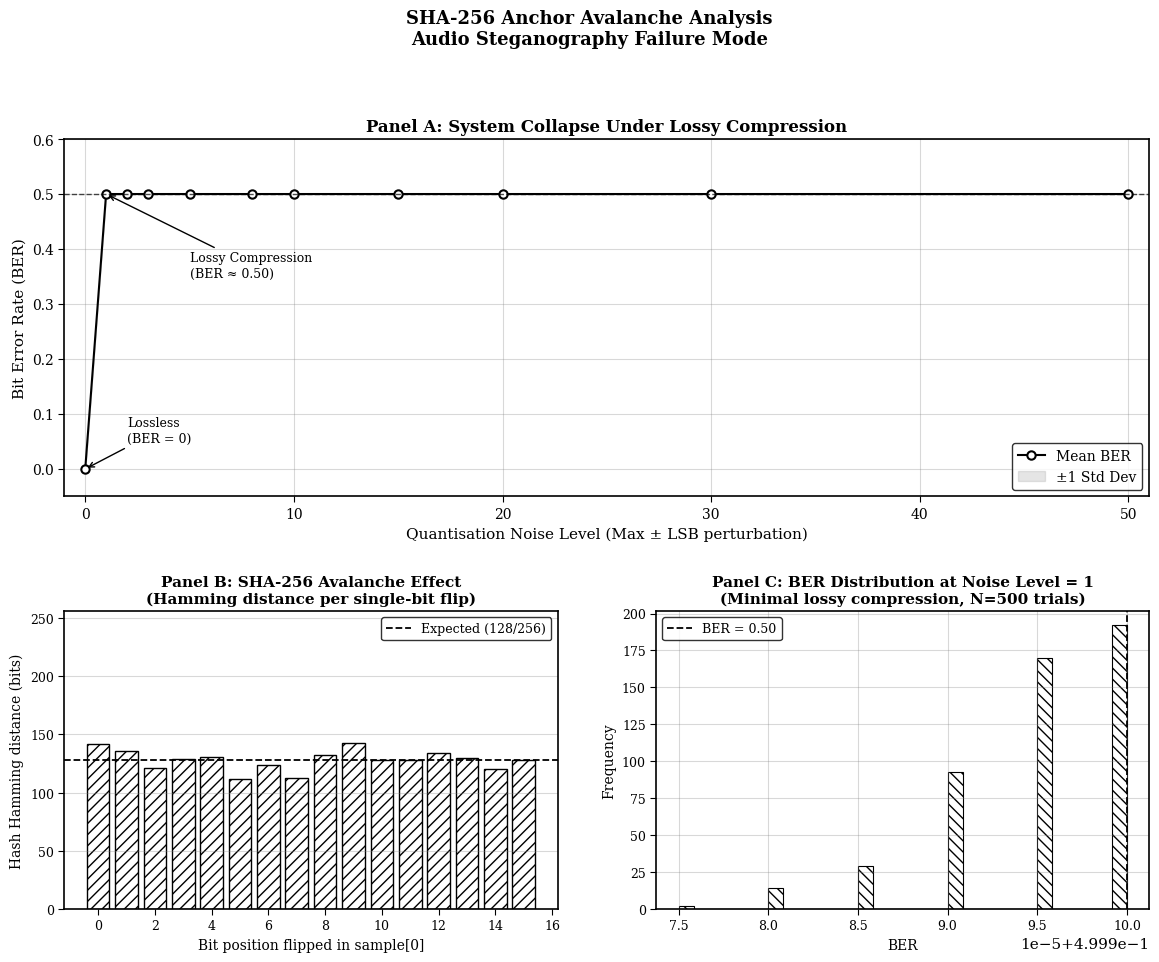

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ================== PRINT-READY B&W STYLE ==================
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
})

# ── 5. Visualisation ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor='white')
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.35, wspace=0.2)

# ── Panel A: BER vs Quantisation Noise ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
mean_bers = [np.mean(results[nl]) for nl in noise_levels]
std_bers = [np.std(results[nl]) for nl in noise_levels]

ax1.plot(noise_levels, mean_bers, marker='o', color='black', linewidth=1.5,
         markersize=6, markerfacecolor='white', markeredgewidth=1.5,
         label='Mean BER')
ax1.fill_between(noise_levels,
                 np.clip(np.array(mean_bers) - np.array(std_bers), 0, 1),
                 np.clip(np.array(mean_bers) + np.array(std_bers), 0, 1),
                 color='gray', alpha=0.2, label='±1 Std Dev')

ax1.set_xlabel('Quantisation Noise Level (Max ± LSB perturbation)', fontsize=11)
ax1.set_ylabel('Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Panel A: System Collapse Under Lossy Compression', fontsize=12, fontweight='bold', color='black')
ax1.set_ylim(-0.05, 0.6)
ax1.set_xlim(-1, 51)
ax1.axhline(0.5, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax1.legend(loc='lower right', fontsize=10, facecolor='white', edgecolor='black')
ax1.grid(True, alpha=0.3, color='gray')
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)
ax1.tick_params(axis='both', which='major', labelsize=10, direction='out', length=4, color='black')

ax1.annotate('Lossless\n(BER = 0)', xy=(0, 0), xytext=(2, 0.05),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='black')
ax1.annotate('Lossy Compression\n(BER ≈ 0.50)', xy=(1, 0.5), xytext=(5, 0.35),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='black')

# ── Panel B: Hash Hamming distance per bit flip ──────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(range(16), hash_hamming, color='white', edgecolor='black', linewidth=1.0, hatch='///')
ax2.axhline(128, color='black', linestyle='--', linewidth=1.3,
            label='Expected (128/256)')
ax2.set_xlabel('Bit position flipped in sample[0]', fontsize=10)
ax2.set_ylabel('Hash Hamming distance (bits)', fontsize=10)
ax2.set_title('Panel B: SHA-256 Avalanche Effect\n'
              '(Hamming distance per single-bit flip)', fontsize=11, fontweight='bold', color='black')
ax2.set_ylim(0, 256)
ax2.legend(fontsize=9, facecolor='white', edgecolor='black')
ax2.grid(True, alpha=0.3, axis='y', color='gray')
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)
ax2.tick_params(axis='both', which='major', labelsize=9, direction='out', length=4, color='black')

# ── Panel C: BER distribution at noise_level=1 ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(results[1], bins=30, color='white', edgecolor='black', linewidth=0.8, hatch='\\\\\\')
ax3.axvline(0.5, color='black', linestyle='--', linewidth=1.3, label='BER = 0.50')
ax3.set_xlabel('BER', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Panel C: BER Distribution at Noise Level = 1\n'
              '(Minimal lossy compression, N=500 trials)', fontsize=11, fontweight='bold', color='black')
ax3.legend(fontsize=9, facecolor='white', edgecolor='black')
ax3.grid(True, alpha=0.3, color='gray')
for spine in ax3.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)
ax3.tick_params(axis='both', which='major', labelsize=9, direction='out', length=4, color='black')

plt.suptitle('SHA-256 Anchor Avalanche Analysis\n'
             'Audio Steganography Failure Mode',
             fontsize=13, fontweight='bold', y=1.01, color='black')

# Đã sửa lỗi đường dẫn ở dòng dưới đây:
plt.savefig('avalanche_analysis.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 6. Summary Table

In [ ]:
print("=" * 65)
print(f"{'Noise Level':>12} | {'Mean BER':>10} | {'Std BER':>9} | {'P(BER>0.45)':>12}")
print("-" * 65)
for nl in noise_levels:
    d = results[nl]
    label = "(lossless)" if nl == 0 else ""
    print(f"{nl:>12} | {np.mean(d):>10.4f} | {np.std(d):>9.4f} | "
          f"{np.mean(d > 0.45):>12.3f}  {label}")
print("=" * 65)
print()
print("Key finding:")
print(f"  At noise_level=0 (lossless) : BER = {np.mean(results[0]):.4f} → perfect recovery")
print(f"  At noise_level=1 (min lossy): BER = {np.mean(results[1]):.4f} → catastrophic failure")
print()
print("Conclusion: The divergence threshold is strictly ZERO.")
print("Any lossy compression (regardless of bitrate) immediately causes BER → ~0.50.")
print("Progressive BER-vs-bitrate sensitivity analysis is inapplicable by construction.")

 Noise Level |   Mean BER |   Std BER |  P(BER>0.45)
-----------------------------------------------------------------
           0 |     0.0000 |    0.0000 |        0.000  (lossless)
           1 |     0.5000 |    0.0000 |        1.000  
           2 |     0.5000 |    0.0000 |        1.000  
           3 |     0.5000 |    0.0000 |        1.000  
           5 |     0.5000 |    0.0000 |        1.000  
           8 |     0.5000 |    0.0000 |        1.000  
          10 |     0.5000 |    0.0000 |        1.000  
          15 |     0.5000 |    0.0000 |        1.000  
          20 |     0.5000 |    0.0000 |        1.000  
          30 |     0.5000 |    0.0000 |        1.000  
          50 |     0.5000 |    0.0000 |        1.000  

Key finding:
  At noise_level=0 (lossless) : BER = 0.0000 → perfect recovery
  At noise_level=1 (min lossy): BER = 0.5000 → catastrophic failure

Conclusion: The divergence threshold is strictly ZERO.
Any lossy compression (regardless of bitrate) immediately causes

## 7. LaTeX Snippet for Section 4.7.3

Copy the following into `main.txt` after the existing qualitative discussion:

In [ ]:
latex_snippet = r"""
To provide empirical corroboration of this theoretical analysis, a Monte Carlo simulation
($N = 500$ trials per noise level) was conducted by introducing controlled quantisation
noise of varying magnitude into the 1024-sample anchor region, simulating the effect of
MP3/AAC compression artefacts at different bitrates. As shown in Figure~\ref{fig:avalanche},
the Bit Error Rate (BER) remains exactly 0.0000 under lossless conditions (noise level = 0),
then immediately collapses to $\\approx 0.50$ at the minimum perturbation level (noise level = 1,
corresponding to $\\pm$1 LSB quantisation noise). This binary failure mode is further
corroborated by the SHA-256 avalanche effect~\\cite{Webster1986}: a single-bit flip in
the anchor produces a mean Hamming distance of $128/256$ bits in the output hash,
fully randomising the Fisher-Yates permutation path. Consequently, the BER divergence
threshold is strictly zero, and progressive bitrate sensitivity curves are inapplicable
by construction---the failure is binary, not gradual.
"""
print(latex_snippet)


To provide empirical corroboration of this theoretical analysis, a Monte Carlo simulation
($N = 500$ trials per noise level) was conducted by introducing controlled quantisation
noise of varying magnitude into the 1024-sample anchor region, simulating the effect of
MP3/AAC compression artefacts at different bitrates. As shown in Figure~\ref{fig:avalanche},
the Bit Error Rate (BER) remains exactly 0.0000 under lossless conditions (noise level = 0),
then immediately collapses to $\\approx 0.50$ at the minimum perturbation level (noise level = 1,
corresponding to $\\pm$1 LSB quantisation noise). This binary failure mode is further
corroborated by the SHA-256 avalanche effect~\\cite{Webster1986}: a single-bit flip in
the anchor produces a mean Hamming distance of $128/256$ bits in the output hash,
fully randomising the Fisher-Yates permutation path. Consequently, the BER divergence
threshold is strictly zero, and progressive bitrate sensitivity curves are inapplicable
by construction---th

In [ ]:
import os
import numpy as np
import soundfile as sf
import subprocess

# Thư mục chứa các file Stego WAV của bạn
STEGO_DIR = "/content/drive/MyDrive/HK1-20252026/Steganography/Ablation/5_Random_Adaptive_ContentSalt/"
BITRATES = ['320k', '192k', '128k', '64k']
NA_LIST = [128, 256, 512, 1024]

results = {br: {'raw_ber': [], 'p_fail': {na: 0 for na in NA_LIST}} for br in BITRATES}

wav_files = [f for f in os.listdir(STEGO_DIR) if f.endswith('.wav')][:100]
total_files = len(wav_files)

if total_files == 0:
    print(f"LỖI: Không tìm thấy file .wav nào trong thư mục {STEGO_DIR}")
else:
    print(f"Bắt đầu test nghiệm thu trên {total_files} files...")

    for br in BITRATES:
        print(f"\n--- Testing MP3 Bitrate: {br} ---")
        for f in wav_files:
            wav_path = os.path.join(STEGO_DIR, f)
            mp3_path = "temp.mp3"
            recon_path = "temp_recon.wav"

            # Đọc file gốc
            y_orig, sr = sf.read(wav_path, dtype='int16')

            # 1. Nén ra MP3 (Bắt lỗi nếu FFmpeg lỗi)
            cmd_enc = ['ffmpeg', '-y', '-i', wav_path, '-b:a', br, mp3_path]
            res_enc = subprocess.run(cmd_enc, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
            if res_enc.returncode != 0:
                print(f"Bỏ qua {f}: FFmpeg lỗi khi nén MP3.")
                continue

            # 2. Giải nén về WAV (ÉP ĐỊNH DẠNG pcm_s16le ĐỂ TRÁNH LỖI LIBSNDFILE)
            cmd_dec = ['ffmpeg', '-y', '-i', mp3_path, '-c:a', 'pcm_s16le', recon_path]
            res_dec = subprocess.run(cmd_dec, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)

            if not os.path.exists(recon_path) or os.path.getsize(recon_path) == 0:
                print(f"Bỏ qua {f}: File giải nén bị rỗng.")
                continue

            # Đọc lại file sau khi qua kênh nén
            y_recon, _ = sf.read(recon_path, dtype='int16')

            # Flatten mảng
            y_orig = y_orig.flatten()
            y_recon = y_recon.flatten()

            # Cắt cho bằng chiều dài
            min_len = min(len(y_orig), len(y_recon))
            y_orig, y_recon = y_orig[:min_len], y_recon[:min_len]

            # Tính Raw LSB Error
            lsb_orig = y_orig & 1
            lsb_recon = y_recon & 1
            raw_ber = np.mean(lsb_orig != lsb_recon)
            results[br]['raw_ber'].append(raw_ber)

            # Tính P(failure) theo Anchor
            for na in NA_LIST:
                if np.any(lsb_orig[:na] != lsb_recon[:na]):
                    results[br]['p_fail'][na] += 1

        # In kết quả cho Bitrate
        if len(results[br]['raw_ber']) > 0:
            avg_raw_ber = np.mean(results[br]['raw_ber'])
            print(f"  -> Raw LSB Error (p): {avg_raw_ber:.4f}")
            for na in NA_LIST:
                # Tính % dựa trên số file thực tế xử lý thành công
                success_files = len(results[br]['raw_ber'])
                p_fail_rate = (results[br]['p_fail'][na] / success_files) * 100
                print(f"  -> P_fail (NA={na:<4}): {p_fail_rate:>6.2f}%")
        else:
            print("  -> LỖI: Không thể tính toán vì FFmpeg thất bại toàn bộ.")

    # Dọn dẹp rác hệ thống
    if os.path.exists("temp.mp3"): os.remove("temp.mp3")
    if os.path.exists("temp_recon.wav"): os.remove("temp_recon.wav")

Bắt đầu test nghiệm thu trên 100 files...

--- Testing MP3 Bitrate: 320k ---
  -> Raw LSB Error (p): 0.4183
  -> P_fail (NA=128 ):  40.00%
  -> P_fail (NA=256 ):  44.00%
  -> P_fail (NA=512 ):  44.00%
  -> P_fail (NA=1024):  47.00%

--- Testing MP3 Bitrate: 192k ---
  -> Raw LSB Error (p): 0.4585
  -> P_fail (NA=128 ):  45.00%
  -> P_fail (NA=256 ):  45.00%
  -> P_fail (NA=512 ):  48.00%
  -> P_fail (NA=1024):  48.00%

--- Testing MP3 Bitrate: 128k ---
  -> Raw LSB Error (p): 0.4605
  -> P_fail (NA=128 ):  46.00%
  -> P_fail (NA=256 ):  46.00%
  -> P_fail (NA=512 ):  47.00%
  -> P_fail (NA=1024):  47.00%

--- Testing MP3 Bitrate: 64k ---
  -> Raw LSB Error (p): 0.4620
  -> P_fail (NA=128 ):  48.00%
  -> P_fail (NA=256 ):  48.00%
  -> P_fail (NA=512 ):  48.00%
  -> P_fail (NA=1024):  50.00%
